In [1]:
import os
import csv
import pandas as pd
import numpy as np
from phe import paillier
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from math import ceil

In [2]:
df = pd.read_csv('Structured_Data.csv')
df.head()

,Age,Sex,ChestPainType,RestingBloodPressure,Cholesterol,FastingBloodSugar,RestingECG,MaximumHeartRate,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,Male,Atypical Angina,140.0,289.0,No,Normal,172.0,No,0.0,Upsloping,No
1,49,Female,Non-anginal Pain,160.0,180.0,No,Normal,156.0,No,1.0,Flat,Yes
2,37,Male,Atypical Angina,130.0,283.0,No,Abnormal ST-T Wave,98.0,No,0.0,Upsloping,No
3,48,Female,Asymptomatic,138.0,214.0,No,Normal,108.0,Yes,1.5,Flat,Yes
4,54,Male,Non-anginal Pain,150.0,195.0,No,Normal,122.0,No,0.0,Upsloping,No


In [3]:
rows_with_missing_data = df[df.isnull().sum(axis=1) >= 1]
df = df.drop(rows_with_missing_data.index)
len(df)

3250

In [4]:
for column in df.columns:
    missing_values_count = df[column].isnull().sum()
    print(f"{column}: {missing_values_count} missing values")

Age: 0 missing values
Sex: 0 missing values
ChestPainType: 0 missing values
RestingBloodPressure: 0 missing values
Cholesterol: 0 missing values
FastingBloodSugar: 0 missing values
RestingECG: 0 missing values
MaximumHeartRate: 0 missing values
ExerciseAngina: 0 missing values
Oldpeak: 0 missing values
ST_Slope: 0 missing values
HeartDisease: 0 missing values


In [5]:
median_resting_blood_pressure = df['RestingBloodPressure'].median()
df['RestingBloodPressure'].fillna(median_resting_blood_pressure, inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_16480\2025481563.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['RestingBloodPressure'].fillna(median_resting_blood_pressure, inplace=True)


In [6]:
df_missing = df[df['Cholesterol'].isnull()]
df_not_missing = df.dropna(subset=['Cholesterol'])

X = df_not_missing.drop('Cholesterol', axis=1) 
y = df_not_missing['Cholesterol']

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')) 
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('onehot', OneHotEncoder(drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

pipeline.fit(X, y)

if len(df_missing) !=0:
    imputed_values = pipeline.predict(df_missing.drop('Cholesterol', axis=1))
    imputed_values_rounded = np.ceil(imputed_values)

    df_missing['Cholesterol'] = imputed_values_rounded
    df_imputed = pd.concat([df_not_missing, df_missing])

    df['Cholesterol'] = df_imputed['Cholesterol']
df

,Age,Sex,ChestPainType,RestingBloodPressure,Cholesterol,FastingBloodSugar,RestingECG,MaximumHeartRate,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,Male,Atypical Angina,140.0,289.0,No,Normal,172.0,No,0.0,Upsloping,No
1,49,Female,Non-anginal Pain,160.0,180.0,No,Normal,156.0,No,1.0,Flat,Yes
2,37,Male,Atypical Angina,130.0,283.0,No,Abnormal ST-T Wave,98.0,No,0.0,Upsloping,No
3,48,Female,Asymptomatic,138.0,214.0,No,Normal,108.0,Yes,1.5,Flat,Yes
4,54,Male,Non-anginal Pain,150.0,195.0,No,Normal,122.0,No,0.0,Upsloping,No
...,...,...,...,...,...,...,...,...,...,...,...,...
4039,68,Female,Non-anginal Pain,120.0,211.0,No,Normal,115.0,No,1.5,Flat,Yes
4040,44,Female,Non-anginal Pain,108.0,141.0,No,Abnormal ST-T Wave,175.0,No,0.6,Flat,Yes
4041,52,Male,Typical Angina,128.0,255.0,No,Abnormal ST-T Wave,161.0,Yes,0.0,Downsloping,No
4042,59,Male,Asymptomatic,160.0,273.0,No,Normal,125.0,No,0.0,Downsloping,No


In [7]:
mode_fasting_blood_sugar = df['FastingBloodSugar'].mode()[0]
df['FastingBloodSugar'].fillna(mode_fasting_blood_sugar, inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_16480\124238313.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FastingBloodSugar'].fillna(mode_fasting_blood_sugar, inplace=True)


In [8]:
mode_st_slope = df['RestingECG'].mode()[0]
df['RestingECG'].fillna(mode_st_slope, inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_16480\230743881.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['RestingECG'].fillna(mode_st_slope, inplace=True)


In [9]:
df_missing = df[df['Oldpeak'].isnull()]
df_not_missing = df.dropna(subset=['Oldpeak'])

X = df_not_missing.drop('Oldpeak', axis=1) 
y = df_not_missing['Oldpeak']

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')) 
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('onehot', OneHotEncoder(drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

pipeline.fit(X, y)

if len(df_missing) != 0:
    imputed_values = pipeline.predict(df_missing.drop('Oldpeak', axis=1))
    imputed_values_rounded = np.ceil(imputed_values)

    df_missing['Oldpeak'] = imputed_values_rounded
    df_imputed = pd.concat([df_not_missing, df_missing])

    df['Oldpeak'] = df_imputed['Oldpeak']
df

,Age,Sex,ChestPainType,RestingBloodPressure,Cholesterol,FastingBloodSugar,RestingECG,MaximumHeartRate,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,Male,Atypical Angina,140.0,289.0,No,Normal,172.0,No,0.0,Upsloping,No
1,49,Female,Non-anginal Pain,160.0,180.0,No,Normal,156.0,No,1.0,Flat,Yes
2,37,Male,Atypical Angina,130.0,283.0,No,Abnormal ST-T Wave,98.0,No,0.0,Upsloping,No
3,48,Female,Asymptomatic,138.0,214.0,No,Normal,108.0,Yes,1.5,Flat,Yes
4,54,Male,Non-anginal Pain,150.0,195.0,No,Normal,122.0,No,0.0,Upsloping,No
...,...,...,...,...,...,...,...,...,...,...,...,...
4039,68,Female,Non-anginal Pain,120.0,211.0,No,Normal,115.0,No,1.5,Flat,Yes
4040,44,Female,Non-anginal Pain,108.0,141.0,No,Abnormal ST-T Wave,175.0,No,0.6,Flat,Yes
4041,52,Male,Typical Angina,128.0,255.0,No,Abnormal ST-T Wave,161.0,Yes,0.0,Downsloping,No
4042,59,Male,Asymptomatic,160.0,273.0,No,Normal,125.0,No,0.0,Downsloping,No


In [10]:
mode_st_slope = df['ST_Slope'].mode()[0]
df['ST_Slope'].fillna(mode_st_slope, inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_16480\1061480930.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ST_Slope'].fillna(mode_st_slope, inplace=True)


In [11]:
for column in df.columns:
    missing_values_count = df[column].isnull().sum()
    print(f"{column}: {missing_values_count} missing values")

Age: 0 missing values
Sex: 0 missing values
ChestPainType: 0 missing values
RestingBloodPressure: 0 missing values
Cholesterol: 0 missing values
FastingBloodSugar: 0 missing values
RestingECG: 0 missing values
MaximumHeartRate: 0 missing values
ExerciseAngina: 0 missing values
Oldpeak: 0 missing values
ST_Slope: 0 missing values
HeartDisease: 0 missing values


<Axes: xlabel='Sex'>

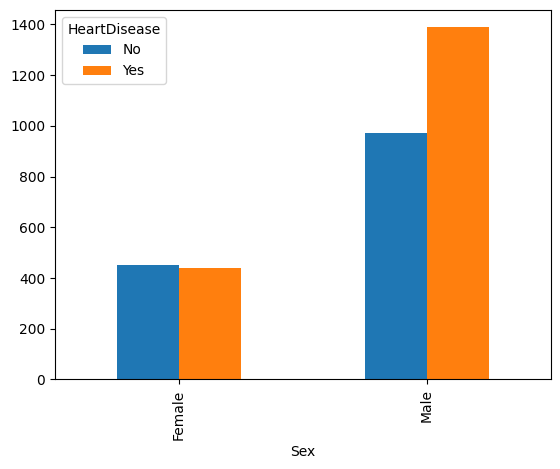

In [12]:
pd.crosstab(df.Sex,df.HeartDisease).plot(kind='bar')

<Axes: xlabel='ChestPainType'>

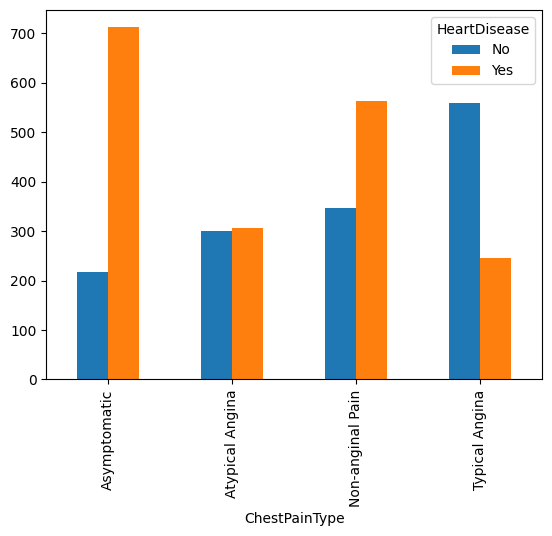

In [13]:
pd.crosstab(df.ChestPainType,df.HeartDisease).plot(kind='bar')

<Axes: xlabel='FastingBloodSugar'>

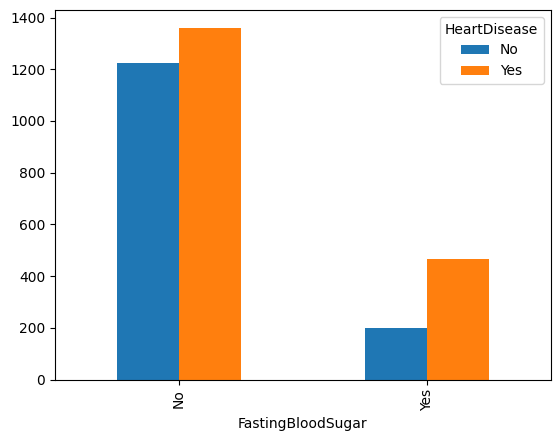

In [14]:
pd.crosstab(df.FastingBloodSugar,df.HeartDisease).plot(kind='bar')

<Axes: xlabel='RestingECG'>

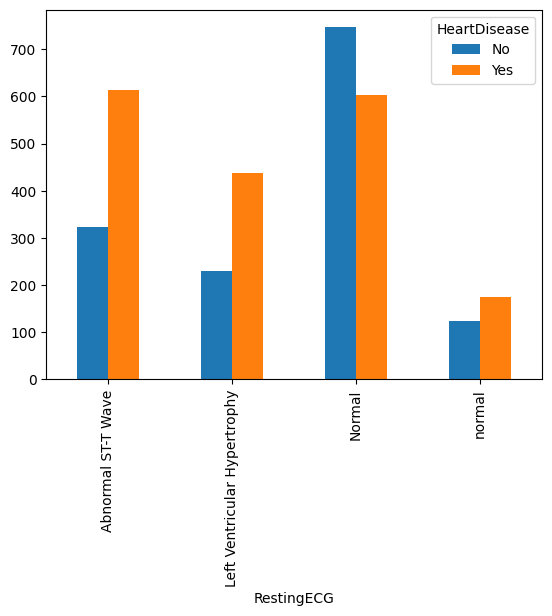

In [15]:
pd.crosstab(df.RestingECG,df.HeartDisease).plot(kind='bar')

<Axes: xlabel='ExerciseAngina'>

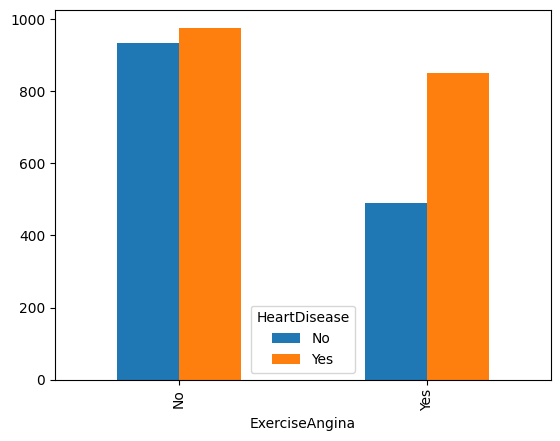

In [16]:
pd.crosstab(df.ExerciseAngina,df.HeartDisease).plot(kind='bar')

<Axes: xlabel='ST_Slope'>

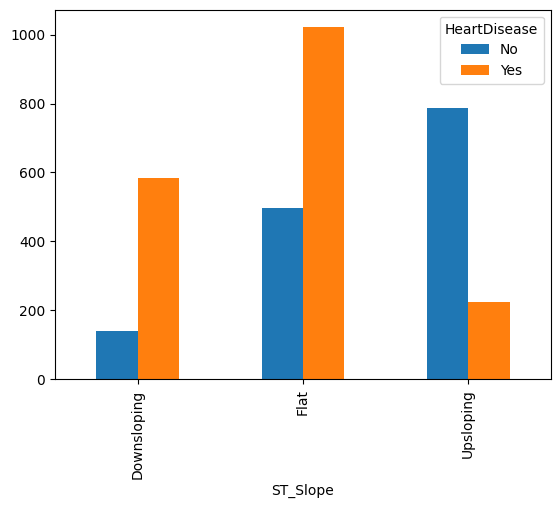

In [17]:
pd.crosstab(df.ST_Slope,df.HeartDisease).plot(kind='bar')

In [18]:
df['Sex']=LabelEncoder().fit_transform(df['Sex'])
df['ChestPainType']=LabelEncoder().fit_transform(df['ChestPainType'])
df['FastingBloodSugar']=LabelEncoder().fit_transform(df['FastingBloodSugar'])
df['RestingECG']=LabelEncoder().fit_transform(df['RestingECG'])
df['ExerciseAngina']=LabelEncoder().fit_transform(df['ExerciseAngina'])
df['ST_Slope']=LabelEncoder().fit_transform(df['ST_Slope'])
df['HeartDisease'] = df['HeartDisease'].replace({'No': 0, 'Yes': 1})
df

C:\Users\USER\AppData\Local\Temp\ipykernel_16480\2247751081.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['HeartDisease'] = df['HeartDisease'].replace({'No': 0, 'Yes': 1})


,Age,Sex,ChestPainType,RestingBloodPressure,Cholesterol,FastingBloodSugar,RestingECG,MaximumHeartRate,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140.0,289.0,0,2,172.0,0,0.0,2,0
1,49,0,2,160.0,180.0,0,2,156.0,0,1.0,1,1
2,37,1,1,130.0,283.0,0,0,98.0,0,0.0,2,0
3,48,0,0,138.0,214.0,0,2,108.0,1,1.5,1,1
4,54,1,2,150.0,195.0,0,2,122.0,0,0.0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4039,68,0,2,120.0,211.0,0,2,115.0,0,1.5,1,1
4040,44,0,2,108.0,141.0,0,0,175.0,0,0.6,1,1
4041,52,1,3,128.0,255.0,0,0,161.0,1,0.0,0,0
4042,59,1,0,160.0,273.0,0,2,125.0,0,0.0,0,0


In [19]:
os.chdir('..')
output_file = '3_Encoded_Dataset/Encoded_Data.csv'
os.chdir(os.getcwd())

df.to_csv(output_file, index=False)

In [20]:
public_key, _ = paillier.generate_paillier_keypair()

public_key_file_path = '3_Encoded_Dataset/Public_Key.pkl'

with open(public_key_file_path, 'wb') as public_key_file:
    pickle.dump(public_key, public_key_file)